In [59]:
import pandas as pd
import numpy as np

In [ ]:
df=pd.read_csv('student_success_dataset.csv')

In [61]:
df.head()

,StudyHours,Attendance,PastScore,Internet,SleepHours,Passed
0,2,60,40,Yes,5,No
1,5,80,65,No,6,Yes
2,6,85,70,Yes,7,Yes
3,1,50,30,No,4,No
4,3,70,55,Yes,6,Yes


In [62]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   StudyHours  20 non-null     int64
 1   Attendance  20 non-null     int64
 2   PastScore   20 non-null     int64
 3   Internet    20 non-null     str  
 4   SleepHours  20 non-null     int64
 5   Passed      20 non-null     str  
dtypes: int64(4), str(2)
memory usage: 1.1 KB


In [63]:
df.columns


Index(['StudyHours', 'Attendance', 'PastScore', 'Internet', 'SleepHours',
       'Passed'],
      dtype='str')

In [64]:
print(df.isnull().sum())

StudyHours    0
Attendance    0
PastScore     0
Internet      0
SleepHours    0
Passed        0
dtype: int64


In [65]:
encoded_df=pd.get_dummies(df, dtype=int,drop_first=True)

In [66]:
encoded_df.head()

,StudyHours,Attendance,PastScore,SleepHours,Internet_Yes,Passed_Yes
0,2,60,40,5,1,0
1,5,80,65,6,0,1
2,6,85,70,7,1,1
3,1,50,30,4,0,0
4,3,70,55,6,1,1


In [67]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [68]:
X=encoded_df.drop('Passed_Yes',axis=1)
y=encoded_df['Passed_Yes']

In [69]:
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.2,random_state=42)

In [70]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [71]:
model=LogisticRegression()
model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [72]:
y_pred=model.predict(X_test)

In [73]:
print("Classification Report:\n",classification_report(y_test,y_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.67      1.00      0.80         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4

Confusion Matrix:
 [[1 1]
 [0 2]]


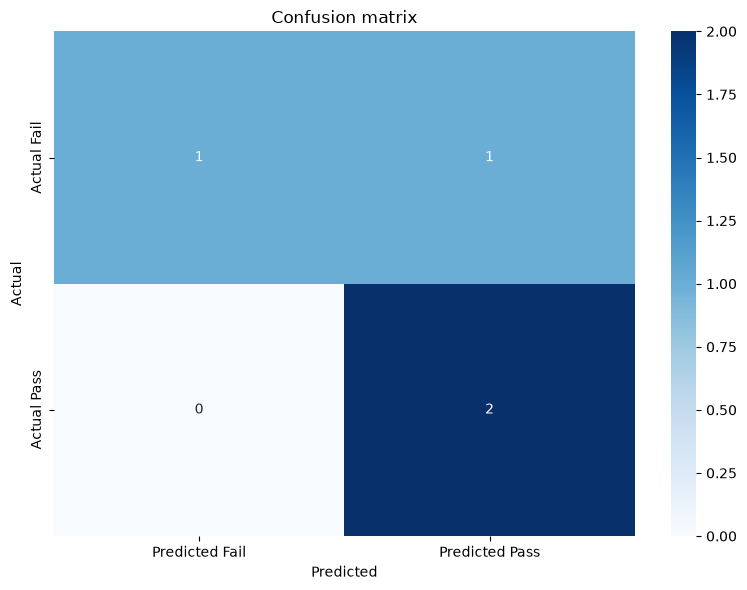

---predict Your result---
The predicted result is: Pass


In [74]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='d',cmap='Blues',
                    xticklabels=['Predicted Fail','Predicted Pass'],
                    yticklabels=['Actual Fail','Actual Pass'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion matrix')
plt.tight_layout()
plt.show()



print("---predict Your result---")
try:
    study_hours=float(input("Enter the number of study hours: "))
    attendance=float(input("Enter the attendance percentage: "))
    past_score=float(input("Enter the past score: "))
    sleep_hours=float(input("Enter the number of sleep hours: "))

    user_input=pd.DataFrame([{
        'StudyHours':study_hours,
        'Attendance':attendance,
        'PastScore':past_score,
        'SleepHours':sleep_hours,
        'Internet_Yes':0,
    }])

    user_input_scaled=scaler.transform(user_input)
    prediction=model.predict(user_input_scaled)[0]

    result="Pass" if prediction==1 else "Fail"
    print(f"The predicted result is: {result}")
except ValueError:
    print("Invalid input. Please enter numeric values for study hours, attendance, past score, and sleep hours.")
